In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors
import networkx as nx
import copy

In [69]:
# ==============================
# PARÂMETROS GERAIS
# ==============================

L = 100
n_lagartos = L**2
estrategias = ['O', 'Y', 'B', 'E']

b = 2
c = 0.5

matriz_payoff = np.array([[1, c, b, 0],
                          [b, 1, c, 0],
                          [c, b, 1, 0],
                          [0, 0, 0, 0]])

index_map = {'O': 0, 'Y': 1, 'B': 2, 'E': 3}

n_geracoes = 50
n_pop = 1
sobreposicao = "s"
A = 0.05
wO = 0.45
wB = 0.45
wY = 0.45
m = 1


output_dir = f"C:/Unicamp/mestrado/simulacoes/main/RPS-diffusion/outputs/test/"
os.makedirs(output_dir, exist_ok=True)

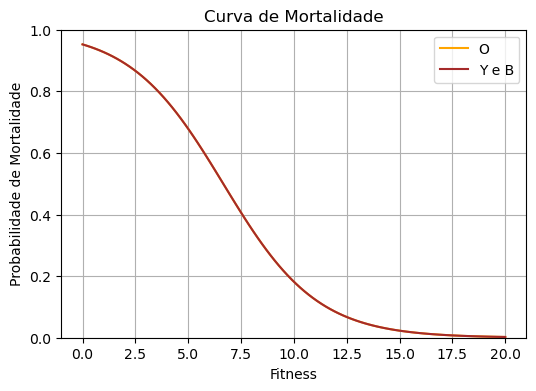

In [70]:
def mortalidade(fitness, A, w):
    return 1 / (1 + A * np.exp(w * fitness))

plt.figure(figsize=(6, 4))
x = np.linspace(0, 20, 100)
y0 = mortalidade(x, A = A, w = wO)
y1 = mortalidade(x, A = A, w = wY)
y2 = mortalidade(x, A = A, w = wB)
plt.plot(x, y0, color = 'orange', label = 'O')
plt.plot(x, y1, color = 'brown', label = 'Y e B')
#plt.plot(x, y2)
#plt.plot(x, y3)
#plt.plot(x, y4)
plt.xlabel('Fitness')
plt.ylabel('Probabilidade de Mortalidade')
plt.title('Curva de Mortalidade')
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()

In [71]:
# ==============================
# CLASSE LAGARTO
# ==============================

class Lagarto:
    def __init__(self, i, j, estrategia, fitness,
                 coord_vizinhos, n_vizinhos):
        self.i = i
        self.j = j
        self.estrategia = estrategia
        self.fitness = 0.0
        self.coord_vizinhos = []
        self.n_vizinhos = n_vizinhos


    def calcular_coord_vizinhos(self, L):
        n = self.n_vizinhos
        if n <= 0:
            print("Erro: n_vizinhos <= 0")
            return

        i0, j0 = self.i, self.j

        def moore(r):
            return {
                ((i0 + dx) % L, (j0 + dy) % L)
                for dx in range(-r, r + 1)
                for dy in range(-r, r + 1)
                if not (dx == 0 and dy == 0)
            }

        def von_neumann(r):
            return {
                ((i0 + dx) % L, (j0 + dy) % L)
                for dx in range(-r, r + 1)
                for dy in range(-r, r + 1)
                if (dx != 0 or dy != 0) and (abs(dx) + abs(dy) <= r)
            }
        
        r = int(np.ceil((np.sqrt(1 + n) - 1) / 2))

        vn_r = von_neumann(r)
        mo_r = moore(r)

        if n <= 2 * r * (r + 1):    # faixa Moore(r-1) -> VN(r)
            base = moore(r - 1) if r > 1 else set()
            pool = list(vn_r - base)
        else:                       # faixa VN(r) -> Moore(r)
            base = vn_r
            pool = list(mo_r - base)

        faltam = n - len(base)
        if faltam <= 0:
            extras = []
        else:
            idx = np.random.choice(len(pool), size=faltam, replace=False)
            extras = [pool[k] for k in idx]

        self.coord_vizinhos = list(base) + extras

    def mortalidade(self, A, w):
        d = 1 / (1 + A * np.exp(w * self.fitness))
        a = np.random.rand()
        #print(f"Fitness: {self.fitness:.2f}, Mortalidade: {d:.4f}, Aleatório: {a:.4f}")
        if a < d:
            self.estrategia = 'E'
            #print("Lagarto morreu.")
        else:
            #print("Lagarto sobreviveu.")
            self.estrategia = self.estrategia

    def calcular_fitness_rede(self, G):
        fitness_total = 0.0
        for vizinho in vizinhos_unicos_rede(G, self):
            fitness_total += matriz_payoff[index_map[self.estrategia], index_map[vizinho.estrategia]]
        self.fitness = fitness_total

    def atualizar_links_lagarto(self, G, L, mapa):
        G.remove_edges_from(list(G.edges(self)))

        self.calcular_coord_vizinhos(L)
        #print(f"Vizinhos de ({self.estrategia}, {self.i}, {self.j}): {self.coord_vizinhos}")

        for (ni, nj) in self.coord_vizinhos:
            vizinho = mapa[(ni, nj)]
            G.add_edge(self, vizinho)

    def troca_posicao(self, G, m):
        vizinhos = vizinhos_unicos_rede(G, self)
        #print(f"Vizinhos de ({self.estrategia}): {[v.estrategia for v in vizinhos]}")
        vizinho = np.random.choice(vizinhos)
        #print(f"Vizinho escolhido para troca: ({vizinho.estrategia}, {vizinho.i}, {vizinho.j})")
        prob_migracao = m

        if np.random.rand() < prob_migracao:
            #print(f"Troca de posição entre ({self.estrategia}) e ({vizinho.estrategia})")
            self.estrategia, vizinho.estrategia = vizinho.estrategia, self.estrategia

    def ocupar_posicao(self, G):
        vizinhos = vizinhos_unicos_rede(G, self)
        #print(f"Vizinhos de ({self.estrategia}, {self.i}, {self.j}): {[v.estrategia for v in vizinhos]}")
        estrategias_vizinhos = [vizinho.estrategia for vizinho in vizinhos]
        opcoes = [e for e in estrategias_vizinhos if e != 'E']
        #print(f"Opções de ocupação para ({self.estrategia}, {self.i}, {self.j}): {opcoes}")
        if opcoes:
            self.estrategia = np.random.choice(opcoes)

# ==============================
# FUNÇÕES AUXILIARES
# ==============================

def vizinhos_unicos_rede(G, l):
    #return list(set(G.predecessors(no)).union(set(G.successors(no))))
    return list(G.neighbors(l))

def criar_lagartos():
    lista = []
    for i in range(L):
        for j in range(L):
            estrategia = np.random.choice(estrategias)
            lista.append(Lagarto(i, j, estrategia, 0, [], n_vizinhos = 8))
    return lista

def calcular_densidade_estrategia(G, estrategia):
    n = G.number_of_nodes()
    if n == 0:
        return 0.0

    contagem = sum(1 for lagarto in G.nodes if lagarto.estrategia == estrategia)
    return contagem / n

def calcular_densidade_rede(G):
    n = G.number_of_nodes()
    if n == 0:
        return 0.0
    ocupado = sum(1 for lagarto in G.nodes if lagarto.estrategia != 'E')
    return ocupado / n

def calcular_freq_estrategia_rede(G, estrategia):
    n = sum(1 for lagarto in G.nodes if lagarto.estrategia == 'O' or lagarto.estrategia == 'Y' or lagarto.estrategia == 'B')
    if n == 0:
        return 0.0

    contagem = sum(1 for lagarto in G.nodes if lagarto.estrategia == estrategia)
    return contagem / n

def grau_unico(G, l):
    #return len(set(G.predecessors(l)).union(set(G.successors(l))))
    return len(list(G.neighbors(l)))

def media_vizinhos_rede(G, lista_lagartos):
    graus = [grau_unico(G, l) for l in lista_lagartos]
    return np.mean(graus) if len(graus) > 0 else np.nan

def media_vizinhos_por_estrategia_rede(G, lista_lagartos):
    medias = []
    for e in estrategias:
        graus = [grau_unico(G, l) for l in lista_lagartos if l.estrategia == e]
        medias.append(np.mean(graus) if len(graus) > 0 else np.nan)
    return medias

In [75]:
# ==============================
# SIMULAÇÃO
# ==============================

def simulacao(wO, wY, wB, A, m, sobreposicao, seed=None):
    resultados = []

    for pop in range(n_pop):
        if seed is not None:
            np.random.seed(seed + pop)
            
        G = nx.Graph()

        lista_lagartos = criar_lagartos()
        mapa = {(l.i, l.j): l for l in lista_lagartos}

        for lagarto in lista_lagartos:
            G.add_node(lagarto)

        for lagarto in lista_lagartos:
            lagarto.atualizar_links_lagarto(G, L, mapa)

        redes_geracoes = [copy.deepcopy(G)]
        
        matriz_posicao = np.empty((L, L), dtype=object)
        for l in lista_lagartos:
            matriz_posicao[l.i, l.j] = l.estrategia
        
        #print(matriz_posicao)

        freq_O = calcular_freq_estrategia_rede(G, 'O')
        freq_Y = calcular_freq_estrategia_rede(G, 'Y')
        freq_B = calcular_freq_estrategia_rede(G, 'B')
        den_O = calcular_densidade_estrategia(G, 'O')
        den_Y = calcular_densidade_estrategia(G, 'Y')
        den_B = calcular_densidade_estrategia(G, 'B')
        den_ocupacao = calcular_densidade_rede(G)
        vizinhos_mean = media_vizinhos_rede(G, lista_lagartos)

        resultados.append({
            "pop": pop,
            "t": -1,
            "freq_O": freq_O,
            "freq_Y": freq_Y,
            "freq_B": freq_B,
            "vizinhos_mean": vizinhos_mean,
            "den_O": den_O,
            "den_Y": den_Y,
            "den_B": den_B,
            "den_ocupacao": den_ocupacao,
            "sobreposicao": sobreposicao,
            "wO": wO,
            "wY": wY,
            "wB": wB,
            "A": A,
            "m": m
        })

        for t in range(n_geracoes):
            print(f"População {pop+1} - Geração {t+1}/{n_geracoes}")

            if sobreposicao.lower() == 's':
                lista_lagartos_permutada = np.random.permutation(lista_lagartos)
                for lagarto in lista_lagartos_permutada:
                    if lagarto.estrategia != 'E':
                        x = np.random.rand()
                        if x < 0.5:
                            lagarto.calcular_fitness_rede(G)
                            lagarto.mortalidade(A, wO if lagarto.estrategia == 'O' else wY if lagarto.estrategia == 'Y' else wB)
                        else:
                            lagarto.troca_posicao(G, m=m)
                    else:
                        lagarto.ocupar_posicao(G)
            
            redes_geracoes.append(copy.deepcopy(G))

            for l in lista_lagartos:
                matriz_posicao[l.i, l.j] = l.estrategia

            freq_O = calcular_freq_estrategia_rede(G, 'O')
            freq_Y = calcular_freq_estrategia_rede(G, 'Y')
            freq_B = calcular_freq_estrategia_rede(G, 'B')
            den_O = calcular_densidade_estrategia(G, 'O')
            den_Y = calcular_densidade_estrategia(G, 'Y')
            den_B = calcular_densidade_estrategia(G, 'B')
            den_ocupacao = calcular_densidade_rede(G)
            vizinhos_mean = media_vizinhos_rede(G, lista_lagartos)

            resultados.append({
                "pop": pop,
                "t": t,
                "freq_O": freq_O,
                "freq_Y": freq_Y,
                "freq_B": freq_B,
                "vizinhos_mean": vizinhos_mean,
                "den_O": den_O,
                "den_Y": den_Y,
                "den_B": den_B,
                "den_ocupacao": den_ocupacao,
                "sobreposicao": sobreposicao,
                "wO": wO,
                "wY": wY,
                "wB": wB,
                "A": A,
                "m": m
            })

    return pd.DataFrame(resultados)

In [76]:
df = simulacao(wO, wY, wB, A, m, sobreposicao, seed=42)

População 1 - Geração 1/50
População 1 - Geração 2/50
População 1 - Geração 3/50
População 1 - Geração 4/50
População 1 - Geração 5/50
População 1 - Geração 6/50
População 1 - Geração 7/50
População 1 - Geração 8/50
População 1 - Geração 9/50
População 1 - Geração 10/50
População 1 - Geração 11/50
População 1 - Geração 12/50
População 1 - Geração 13/50
População 1 - Geração 14/50
População 1 - Geração 15/50
População 1 - Geração 16/50
População 1 - Geração 17/50
População 1 - Geração 18/50
População 1 - Geração 19/50
População 1 - Geração 20/50
População 1 - Geração 21/50
População 1 - Geração 22/50
População 1 - Geração 23/50
População 1 - Geração 24/50
População 1 - Geração 25/50
População 1 - Geração 26/50
População 1 - Geração 27/50
População 1 - Geração 28/50
População 1 - Geração 29/50
População 1 - Geração 30/50
População 1 - Geração 31/50
População 1 - Geração 32/50
População 1 - Geração 33/50
População 1 - Geração 34/50
População 1 - Geração 35/50
População 1 - Geração 36/50
P

In [74]:
df

,pop,t,freq_O,freq_Y,freq_B,vizinhos_mean,den_O,den_Y,den_B,den_ocupacao,sobreposicao,wO,wY,wB,A,m
0,0,-1,0.338178,0.331511,0.330311,8.0,0.2536,0.2486,0.2477,0.7499,s,0.45,0.45,0.45,0.05,1
1,0,0,0.340484,0.337345,0.322171,8.0,0.2603,0.2579,0.2463,0.7645,s,0.45,0.45,0.45,0.05,1
2,0,1,0.339730,0.338434,0.321836,8.0,0.2620,0.2610,0.2482,0.7712,s,0.45,0.45,0.45,0.05,1
3,0,2,0.332682,0.340755,0.326562,8.0,0.2555,0.2617,0.2508,0.7680,s,0.45,0.45,0.45,0.05,1
4,0,3,0.335193,0.347521,0.317285,8.0,0.2583,0.2678,0.2445,0.7706,s,0.45,0.45,0.45,0.05,1
5,0,4,0.338157,0.346556,0.315286,8.0,0.2617,0.2682,0.2440,0.7739,s,0.45,0.45,0.45,0.05,1
6,0,5,0.333031,0.342365,0.324605,8.0,0.2569,0.2641,0.2504,0.7714,s,0.45,0.45,0.45,0.05,1
7,0,6,0.332510,0.343169,0.324321,8.0,0.2558,0.2640,0.2495,0.7693,s,0.45,0.45,0.45,0.05,1
8,0,7,0.331198,0.344927,0.323876,8.0,0.2533,0.2638,0.2477,0.7648,s,0.45,0.45,0.45,0.05,1
9,0,8,0.326674,0.340963,0.332363,8.0,0.2469,0.2577,0.2512,0.7558,s,0.45,0.45,0.45,0.05,1


In [77]:
# ==============================
# SIMULAÇÃO GIF
# ==============================

def simulacao_gif(wO, wY, wB, A, m, sobreposicao, seed=None):
    resultados = []
    matrizes_posicao_hist = []

    for pop in range(n_pop):
        if seed is not None:
            np.random.seed(seed + pop)
            
        G = nx.Graph()

        lista_lagartos = criar_lagartos()
        mapa = {(l.i, l.j): l for l in lista_lagartos}

        for lagarto in lista_lagartos:
            G.add_node(lagarto)

        for lagarto in lista_lagartos:
            lagarto.atualizar_links_lagarto(G, L, mapa)

        redes_geracoes = [copy.deepcopy(G)]
        
        matriz_posicao = np.empty((L, L), dtype=object)
        for l in lista_lagartos:
            matriz_posicao[l.i, l.j] = l.estrategia
        
        matrizes_posicao_hist.append(matriz_posicao.copy())
        
        #print(matriz_posicao)

        freq_O = calcular_freq_estrategia_rede(G, 'O')
        freq_Y = calcular_freq_estrategia_rede(G, 'Y')
        freq_B = calcular_freq_estrategia_rede(G, 'B')
        den_O = calcular_densidade_estrategia(G, 'O')
        den_Y = calcular_densidade_estrategia(G, 'Y')
        den_B = calcular_densidade_estrategia(G, 'B')
        den_ocupacao = calcular_densidade_rede(G)
        vizinhos_mean = media_vizinhos_rede(G, lista_lagartos)

        resultados.append({
            "pop": pop,
            "t": -1,
            "freq_O": freq_O,
            "freq_Y": freq_Y,
            "freq_B": freq_B,
            "vizinhos_mean": vizinhos_mean,
            "den_O": den_O,
            "den_Y": den_Y,
            "den_B": den_B,
            "den_ocupacao": den_ocupacao,
            "sobreposicao": sobreposicao,
            "wO": wO,
            "wY": wY,
            "wB": wB,
            "A": A,
            "m": m
        })

        for t in range(n_geracoes):
            print(f"População {pop+1} - Geração {t+1}/{n_geracoes}")

            if sobreposicao.lower() == 's':
                lista_lagartos_permutada = np.random.permutation(lista_lagartos)
                for lagarto in lista_lagartos_permutada:
                    if lagarto.estrategia != 'E':
                        x = np.random.rand()
                        if x < 0.5:
                            lagarto.calcular_fitness_rede(G)
                            lagarto.mortalidade(A, wO if lagarto.estrategia == 'O' else wY if lagarto.estrategia == 'Y' else wB)
                        else:
                            lagarto.troca_posicao(G, m=m)
                    else:
                        lagarto.ocupar_posicao(G)
            
            redes_geracoes.append(copy.deepcopy(G))

            for l in lista_lagartos:
                matriz_posicao[l.i, l.j] = l.estrategia
            
            matrizes_posicao_hist.append(matriz_posicao.copy())

            freq_O = calcular_freq_estrategia_rede(G, 'O')
            freq_Y = calcular_freq_estrategia_rede(G, 'Y')
            freq_B = calcular_freq_estrategia_rede(G, 'B')
            den_O = calcular_densidade_estrategia(G, 'O')
            den_Y = calcular_densidade_estrategia(G, 'Y')
            den_B = calcular_densidade_estrategia(G, 'B')
            den_ocupacao = calcular_densidade_rede(G)
            vizinhos_mean = media_vizinhos_rede(G, lista_lagartos)

            resultados.append({
                "pop": pop,
                "t": t,
                "freq_O": freq_O,
                "freq_Y": freq_Y,
                "freq_B": freq_B,
                "vizinhos_mean": vizinhos_mean,
                "den_O": den_O,
                "den_Y": den_Y,
                "den_B": den_B,
                "den_ocupacao": den_ocupacao,
                "sobreposicao": sobreposicao,
                "wO": wO,
                "wY": wY,
                "wB": wB,
                "A": A,
                "m": m
            })

    return pd.DataFrame(resultados), matrizes_posicao_hist

In [78]:
df_gif, matrizes_posicao_hist = simulacao_gif(wO, wY, wB, A, m, sobreposicao, seed=42)

População 1 - Geração 1/50
População 1 - Geração 2/50
População 1 - Geração 3/50
População 1 - Geração 4/50
População 1 - Geração 5/50
População 1 - Geração 6/50
População 1 - Geração 7/50
População 1 - Geração 8/50
População 1 - Geração 9/50
População 1 - Geração 10/50
População 1 - Geração 11/50
População 1 - Geração 12/50
População 1 - Geração 13/50
População 1 - Geração 14/50
População 1 - Geração 15/50
População 1 - Geração 16/50
População 1 - Geração 17/50
População 1 - Geração 18/50
População 1 - Geração 19/50
População 1 - Geração 20/50
População 1 - Geração 21/50
População 1 - Geração 22/50
População 1 - Geração 23/50
População 1 - Geração 24/50
População 1 - Geração 25/50
População 1 - Geração 26/50
População 1 - Geração 27/50
População 1 - Geração 28/50
População 1 - Geração 29/50
População 1 - Geração 30/50
População 1 - Geração 31/50
População 1 - Geração 32/50
População 1 - Geração 33/50
População 1 - Geração 34/50
População 1 - Geração 35/50
População 1 - Geração 36/50
P

In [79]:
# gerando o GIF das posições

cores_grid = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237", "E": "#FFFFFF"}

def matriz_para_rgb(matriz):
    # Converte hex para RGB normalizado (0-1)
    return np.array([[mcolors.to_rgb(cores_grid.get(cell, "#FFFFFF")) for cell in row] for row in matriz])

# Crie a figura
fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    ax.imshow(matriz_para_rgb(matrizes_posicao_hist[frame]))
    ax.set_title(f"Geração {frame}")
    ax.axis('off')

ani = animation.FuncAnimation(
    fig, update, frames=len(matrizes_posicao_hist), interval=100, repeat=False
)

# Salvar como GIF
ani.save(os.path.join(output_dir, f"teste.gif"), writer='pillow', fps=5)
ani.save(os.path.join(output_dir, f"teste.mp4"), writer='ffmpeg', fps=5)
plt.close()